In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


In [2]:
M = .1          # mass
gamma = jnp.sqrt(4.0*M)      # friction
Ntraj = 20000   # number of trajectories
dt = 0.001

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def mu(t,T_slow):
    tau = t / T_slow
    return tau

def mu_prime(t,T_slow):
    return 1/T_slow

In [4]:
def p0(x, v, t,T_slow):
    """
    Adiabatic distribution:
      p0(x,v,t) = [1/sqrt(2*pi)] * exp(-(x - mu(t))^2 / 2)
                  * [1/sqrt(2*pi*M)] * exp(-v^2 / (2M))
    """
    mu_val = mu(t,T_slow)
    norm_x = 1.0 / jnp.sqrt(2.0 * jnp.pi)
    norm_v = 1.0 / jnp.sqrt(2.0 * jnp.pi * M)
    px = norm_x * jnp.exp(-0.5 * (x - mu_val)**2)
    pv = norm_v * jnp.exp(-0.5 * (v**2 / M))
    return px * pv


def p1_factor(x, v, t,T_slow):
    mu_p = mu_prime(t,T_slow)
    mu_val = mu(t,T_slow)
    return mu_p * ( gamma*(x - mu_val)-v)


def p_1st_order(x, v, t, T_slow):
    """
    p^(0) + (1/T_slow) p^(1)
    """
    return p0(x,v,t,T_slow) * (1.0 -  p1_factor(x,v,t,T_slow))
  
  
def numeric_marginal_x(p_func, x_grid, t,T_slow, vmin=-5, vmax=5, nv=200):
    """
    Numerically integrate p_func(x,v,t) over v in [vmin, vmax].
    Return array of shape = len(x_grid).
    """
    vs = jnp.linspace(vmin, vmax, nv)
    dv = vs[1] - vs[0]
    def integrand(v):
        return p_func(x_grid[:,None], v[None,:], t,T_slow)
    vals = integrand(vs)
    # vals shape: (len(x_grid), nv)
    return jnp.trapezoid(vals, dx=dv, axis=1)

def numeric_marginal_v(p_func, v_grid, t,T_slow, xmin=-5, xmax=5, nx=200):
    """
    Numerically integrate p_func(x,v,t) over x in [xmin, xmax].
    """
    xs = jnp.linspace(xmin, xmax, nx)
    dx = xs[1] - xs[0]
    def integrand(x):
        return p_func(x[None,:], v_grid[:,None], t,T_slow)
    vals = integrand(xs)
    # shape: (len(v_grid), nx)
    return jnp.trapezoid(vals, dx=dx, axis=1)



In [5]:
def step(x, v, t, T_slow, key):
    # key -> split for random
    key, subkey = jax.random.split(key)
    xi = jax.random.normal(subkey, shape=x.shape)  # standard normal
    # SDE update
    x_new = x + (v / M) * dt
    v_drift = -((x - mu(t,T_slow)) + (gamma / M) * v)
    v_new = v + v_drift * dt + jnp.sqrt(2.0 * gamma * dt) * xi
    return x_new, v_new, key


def simulate(T_slow, key, T_sim, dt):
    key, sample_key_x, sample_key_v = jax.random.split(key, 3)
    x = jax.random.normal(sample_key_x, shape=(Ntraj,))
    v = jax.random.normal(sample_key_v, shape=(Ntraj,)) * jnp.sqrt(M)  # sample v ~ N(0,M)
    t = 0.0

    n_steps = int(T_sim/dt)
    # For efficiency, pre-split the random keys
    keys = jax.random.split(key, n_steps)
    for i in range(n_steps):
        x, v, _ = step(x, v, t, T_slow, keys[i])
        t += dt
    return x, v

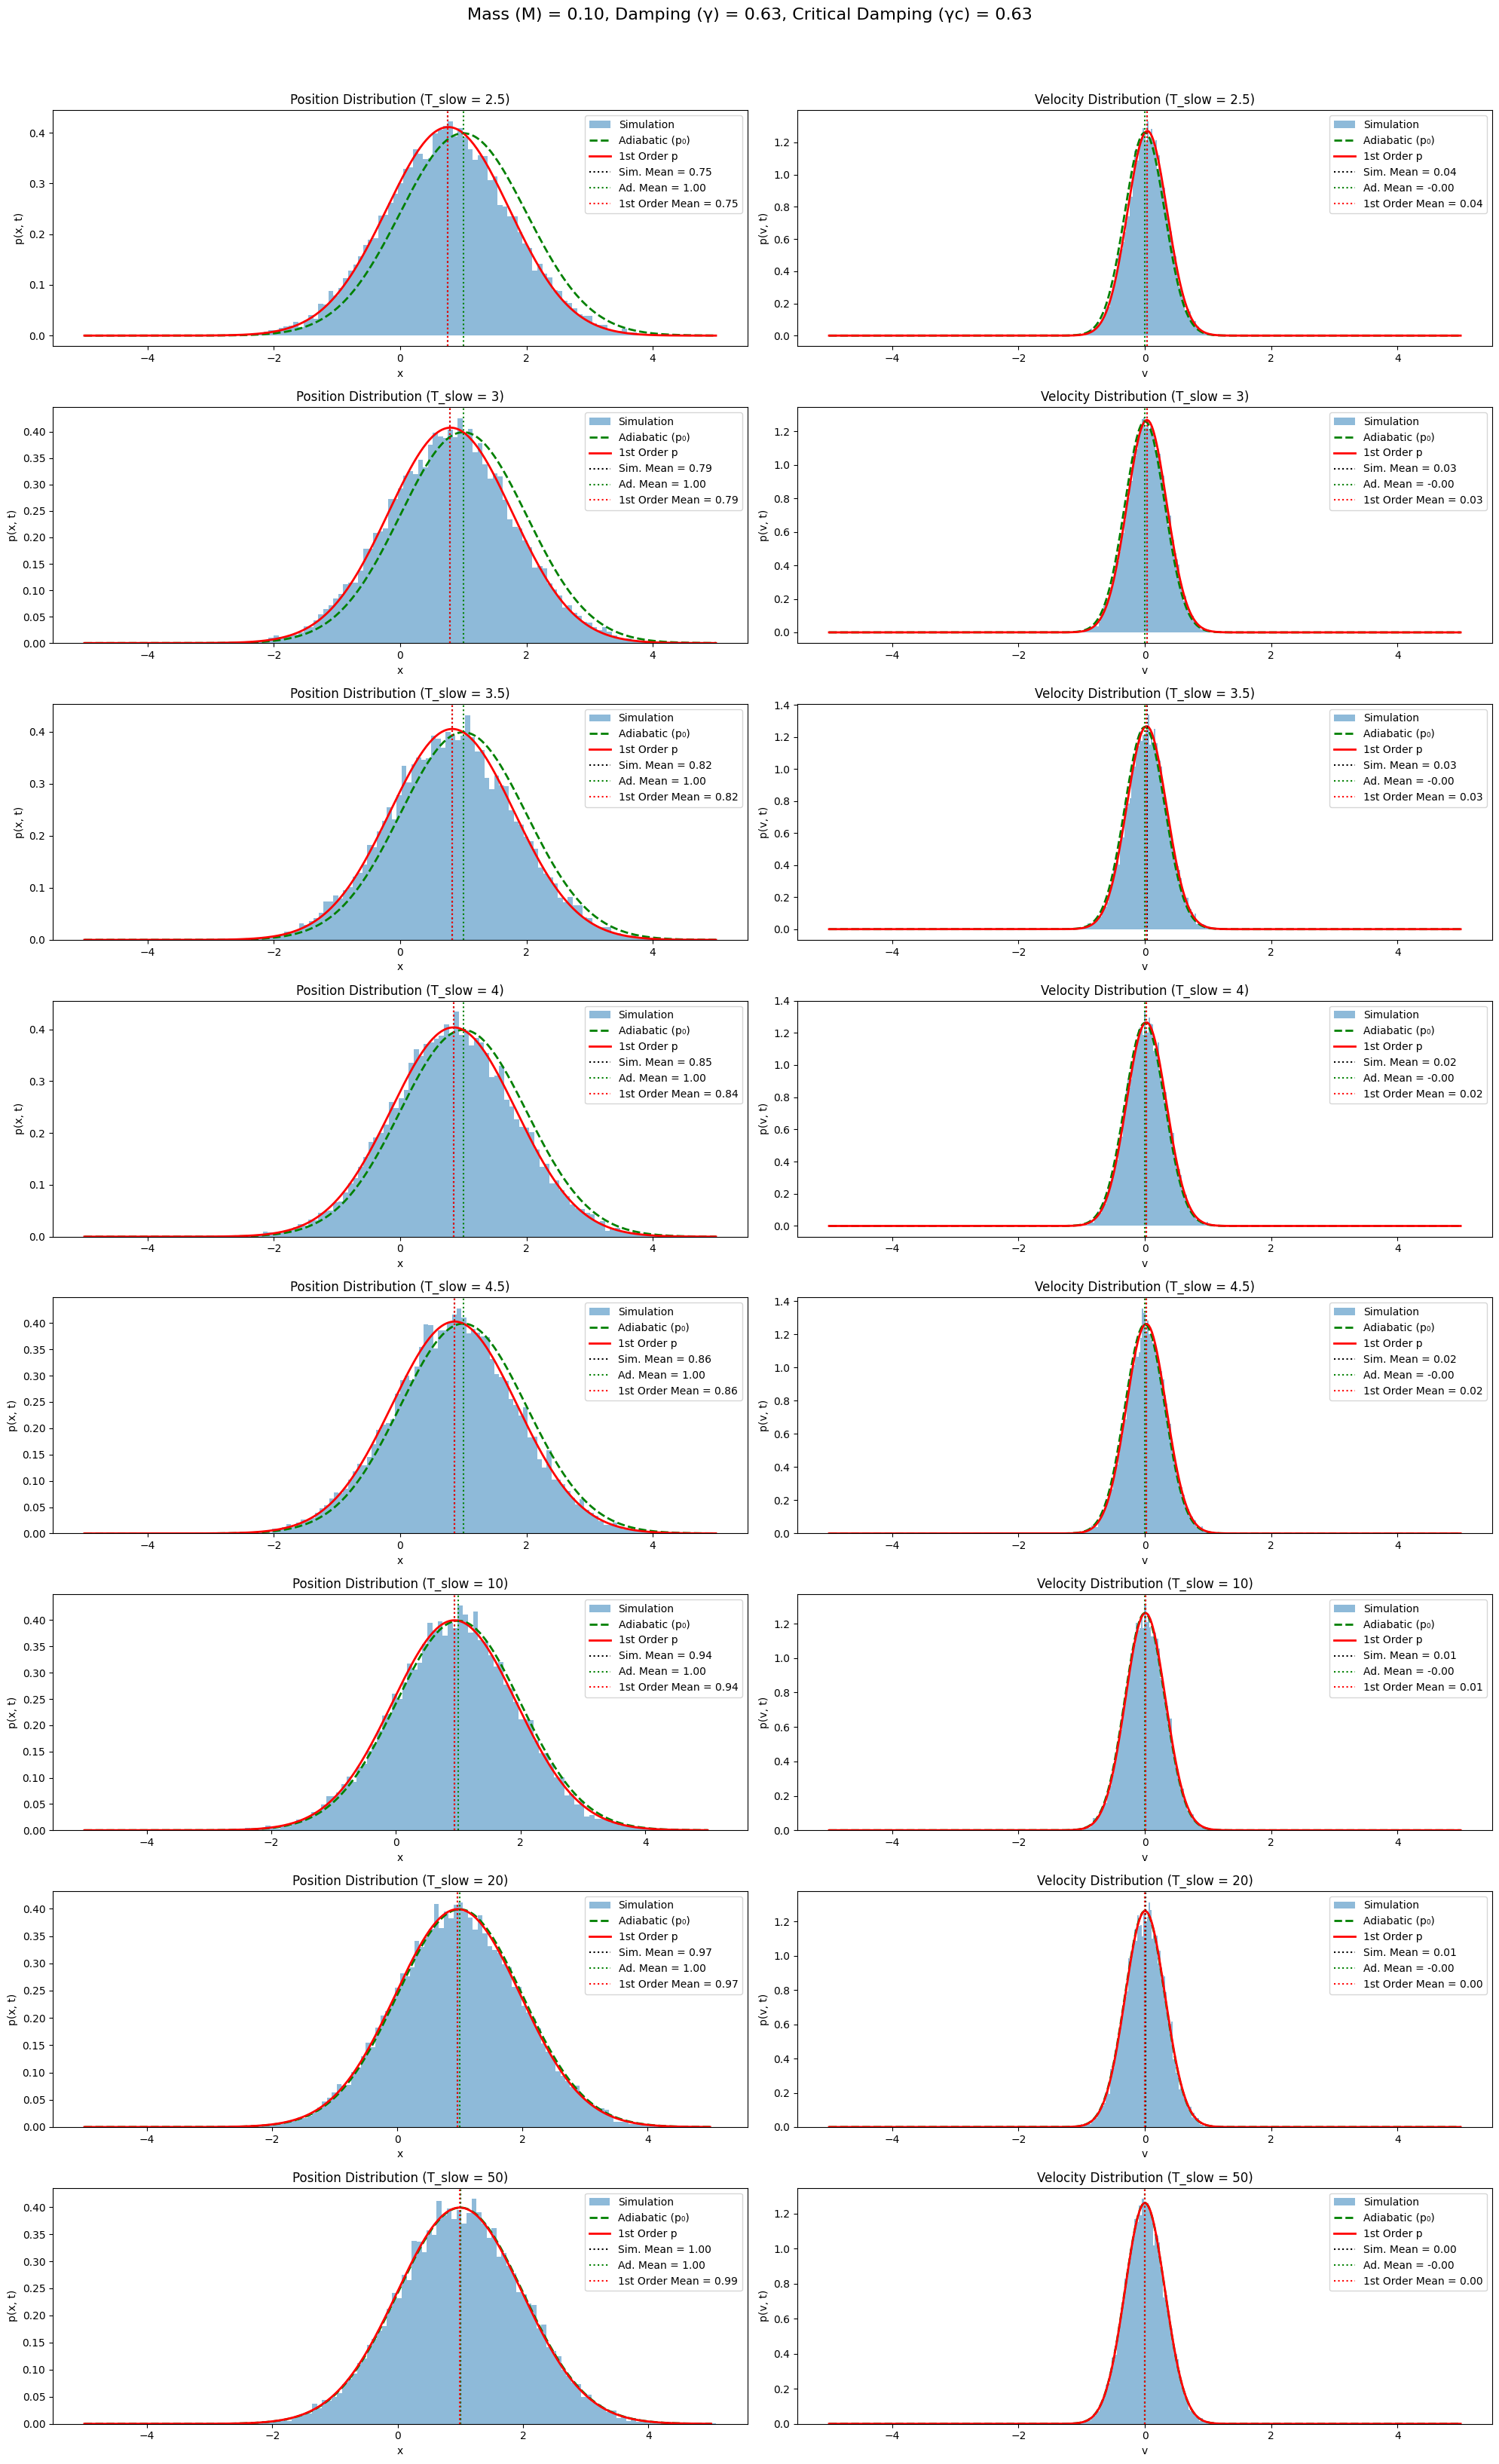

In [6]:
# Choose several slow time scales to test.
T_slow_list = [2.5,3,3.5,4,4.5,10,20,50]
key0 = jax.random.PRNGKey(0)

# Set up a figure with subplots - now 2 columns
n_plots = len(T_slow_list)
fig, axes = plt.subplots(n_plots, 2, figsize=(20, 4*n_plots))

# Add suptitle with system parameters
fig.suptitle(f'Mass (M) = {M:.2f}, Damping (γ) = {gamma:.2f}, Critical Damping (γc) = {jnp.sqrt(4.0*M):.2f}', 
             fontsize=16, y=1.02)

# x and v grids for plotting theoretical curves
x_grid = jnp.linspace(-5, 5, 400)
v_grid = jnp.linspace(-5, 5, 400)

for idx, T_slow in enumerate(T_slow_list):
    key = jax.random.fold_in(key0, int(T_slow))
    T_sim = T_slow
    x_final, v_final = simulate(T_slow, key, T_sim, dt)
    
    # Position distributions (left column)
    ax_x = axes[idx, 0]
    
    # Compute marginal distributions for position
    p0_x = numeric_marginal_x(p0, x_grid, T_sim, T_slow)
    p1st_x = numeric_marginal_x(
        lambda xx, vv, tt, T_slow: p_1st_order(xx, vv, tt, T_slow),
        x_grid, T_sim, T_slow
    )
    
    # Normalize position distributions
    p0_x /= jnp.trapezoid(p0_x, x_grid)
    p1st_x /= jnp.trapezoid(p1st_x, x_grid)
    
    # Compute position means
    mean_x = jnp.mean(x_final)
    dx = x_grid[1] - x_grid[0]
    mean_x_ad = jnp.sum(x_grid * p0_x) * dx
    mean_x_first = jnp.sum(x_grid * p1st_x) * dx
    
    
    # Plot position distributions
    ax_x.hist(x_final, bins=100, density=True, alpha=0.5, label='Simulation')
    ax_x.plot(x_grid, p0_x, 'g--', lw=2, label='Adiabatic (p₀)')
    ax_x.plot(x_grid, p1st_x, 'r-', lw=2, label='1st Order p')
    ax_x.axvline(x=mean_x, color='k', linestyle=':', label=f'Sim. Mean = {mean_x:.2f}')
    ax_x.axvline(x=mean_x_ad, color='g', linestyle=':', label=f'Ad. Mean = {mean_x_ad:.2f}')
    ax_x.axvline(x=mean_x_first, color='r', linestyle=':', label=f'1st Order Mean = {mean_x_first:.2f}')
    ax_x.set_title(f"Position Distribution (T_slow = {T_slow})")
    ax_x.set_xlabel("x")
    ax_x.set_ylabel("p(x, t)")
    ax_x.legend()

    # Velocity distributions (right column)
    ax_v = axes[idx, 1]
    
    # Compute marginal distributions for velocity
    p0_v = numeric_marginal_v(p0, v_grid, T_sim, T_slow)
    p1st_v = numeric_marginal_v(
        lambda xx, vv, tt, T_slow: p_1st_order(xx, vv, tt, T_slow),
        v_grid, T_sim, T_slow
    )
    
    # Normalize velocity distributions
    p0_v /= jnp.trapezoid(p0_v, v_grid)
    p1st_v /= jnp.trapezoid(p1st_v, v_grid)
    
    # Compute velocity means
    mean_v = jnp.mean(v_final)
    dv = v_grid[1] - v_grid[0]
    mean_v_ad = jnp.sum(v_grid * p0_v) * dv
    mean_v_first = jnp.sum(v_grid * p1st_v) * dv
    
    # Plot velocity distributions
    ax_v.hist(v_final, bins=100, density=True, alpha=0.5, label='Simulation')
    ax_v.plot(v_grid, p0_v, 'g--', lw=2, label='Adiabatic (p₀)')
    ax_v.plot(v_grid, p1st_v, 'r-', lw=2, label='1st Order p')
    ax_v.axvline(x=mean_v, color='k', linestyle=':', label=f'Sim. Mean = {mean_v:.2f}')
    ax_v.axvline(x=mean_v_ad, color='g', linestyle=':', label=f'Ad. Mean = {mean_v_ad:.2f}')
    ax_v.axvline(x=mean_v_first, color='r', linestyle=':', label=f'1st Order Mean = {mean_v_first:.2f}')
    ax_v.set_title(f"Velocity Distribution (T_slow = {T_slow})")
    ax_v.set_xlabel("v")
    ax_v.set_ylabel("p(v, t)")
    ax_v.legend()


plt.tight_layout()
plt.savefig(f'underdamped_M_{M:.3f}_gamma_{gamma:.3f}.png', bbox_inches='tight', dpi=300)